In [88]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import DATASET_PATH
import seaborn as sns
import joblib
import os

In [32]:
car_data = pd.read_csv(DATASET_PATH)
car_data.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [33]:
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [34]:
drop_cols = [
    "id",
    "url",
    "region_url",
    "image_url",
    "description",
    "VIN",
    "county",
    "lat",
    "long",
]

car_data = car_data.drop(columns=drop_cols)

In [35]:
car_data.describe(include='all')

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
count,426880,4.268800e+05,425675.000000,409234,421603,252776,249202,423867,4.224800e+05,418638,424324,296313,120519,334022,296677,426880,426812
unique,404,NaN,NaN,42,29667,6,8,5,NaN,6,3,3,4,13,12,51,381536
top,columbus,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,4wd,full-size,sedan,white,ca,2021-04-23T22:13:05-0400
freq,3608,NaN,NaN,70985,8009,121456,94169,356209,NaN,405117,336524,131904,63465,87056,79285,50614,12
mean,NaN,7.519903e+04,2011.235191,NaN,NaN,NaN,NaN,NaN,9.804333e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.218228e+07,9.452120,NaN,NaN,NaN,NaN,NaN,2.138815e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,NaN,3.770400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.395000e+04,2013.000000,NaN,NaN,NaN,NaN,NaN,8.554800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2.648575e+04,2017.000000,NaN,NaN,NaN,NaN,NaN,1.335425e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
missing_percent = car_data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

size            71.767476
cylinders       41.622470
condition       40.785232
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
posting_date     0.015930
price            0.000000
state            0.000000
region           0.000000
dtype: float64

In [37]:
# dropping size, cylinders and condition due to large amount of missing data

car_data = car_data.drop(columns=['size', 'cylinders', 'condition'])
car_data.head()

,region,price,year,manufacturer,model,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


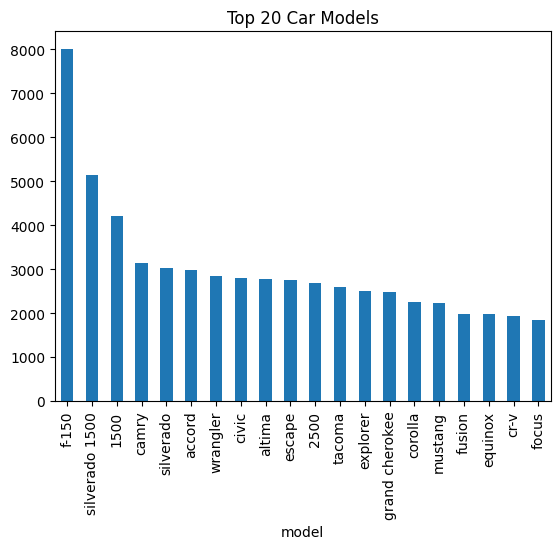

In [38]:
car_data["model"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Car Models")
plt.show()

In [39]:
car_data["model"] = car_data["model"].str.lower().str.strip()
model_counts = car_data["model"].value_counts()
valid_models = model_counts[model_counts >= 200].index
car_data["model"] = car_data["model"].apply(
    lambda x: x if x in valid_models else "other"
)

In [40]:
car_data["model"].nunique()

327

In [41]:
car_data["model"].value_counts().head(20)

model
other             208000
f-150               8075
silverado 1500      5142
1500                4211
camry               3139
silverado           3024
accord              2972
wrangler            2851
civic               2800
altima              2779
escape              2749
2500                2687
tacoma              2583
explorer            2511
grand cherokee      2503
corolla             2242
mustang             2232
fusion              1980
equinox             1972
cr-v                1938
Name: count, dtype: int64

In [45]:
car_data = car_data[(car_data["price"] > 500) & (car_data["price"] < 100000)]

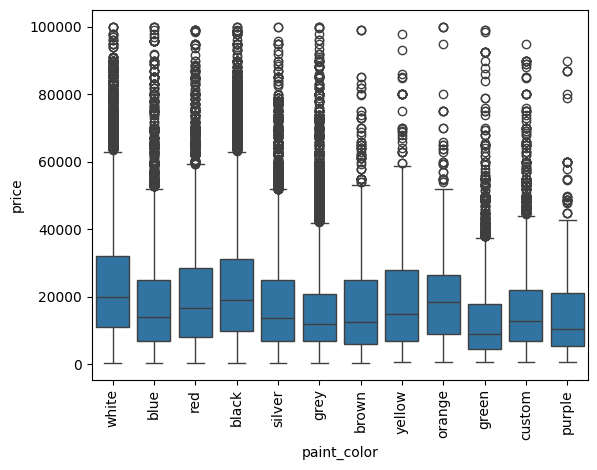

In [49]:
sns.boxplot(x="paint_color", y="price", data=car_data)
plt.xticks(rotation=90)
plt.show()

In [52]:
car_data = car_data[(car_data["odometer"] > 0) & (car_data["odometer"] < 300000)]

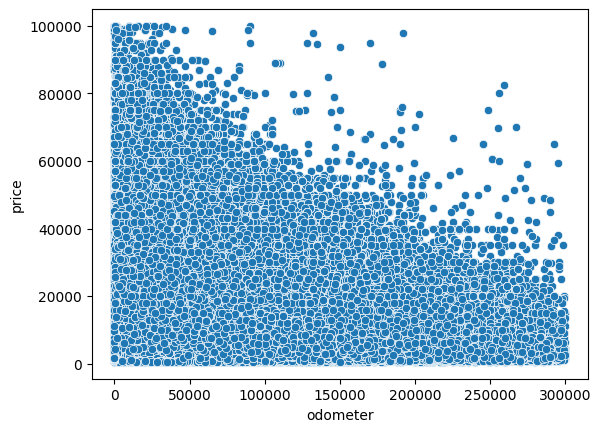

In [58]:
sns.scatterplot(x="odometer", y="price", data=car_data)
plt.show()

In [55]:
car_data = car_data[(car_data["year"] >= 1990) & (car_data["year"] <= 2024)]

In [59]:
car_data["car_age"] = 2024 - car_data["year"]
car_data = car_data.drop(columns=["year"])

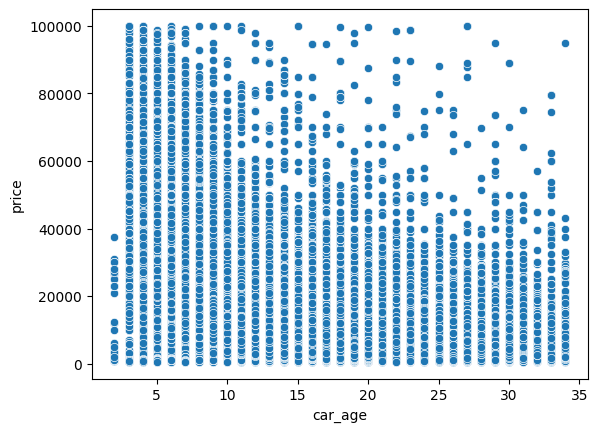

In [65]:
sns.scatterplot(x="car_age", y="price", data=car_data)
plt.show()

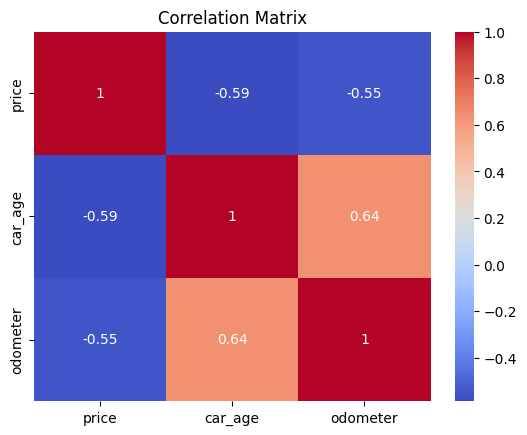

In [62]:
numeric_cols = ["price", "car_age", "odometer"]

sns.heatmap(car_data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

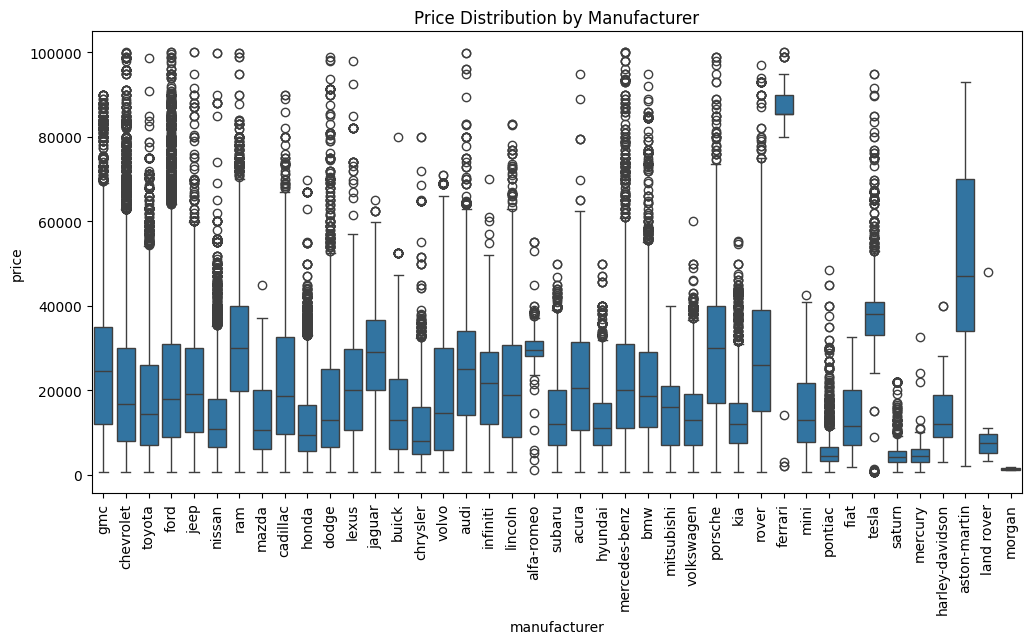

In [67]:
plt.figure(figsize=(12,6))
sns.boxplot(x="manufacturer", y="price", data=car_data)
plt.xticks(rotation=90)
plt.title("Price Distribution by Manufacturer")
plt.show()

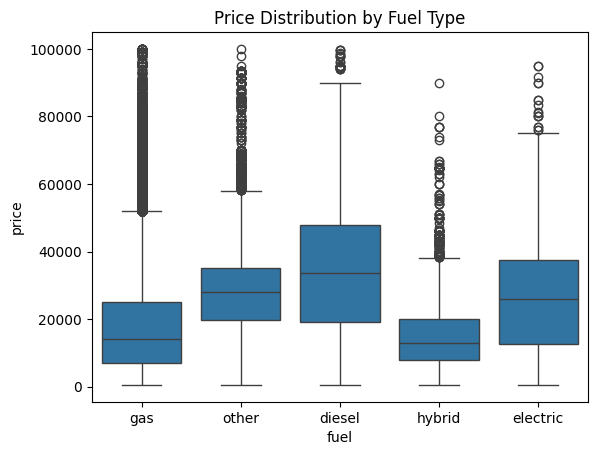

In [68]:
sns.boxplot(x="fuel", y="price", data=car_data)
plt.title("Price Distribution by Fuel Type")
plt.show()

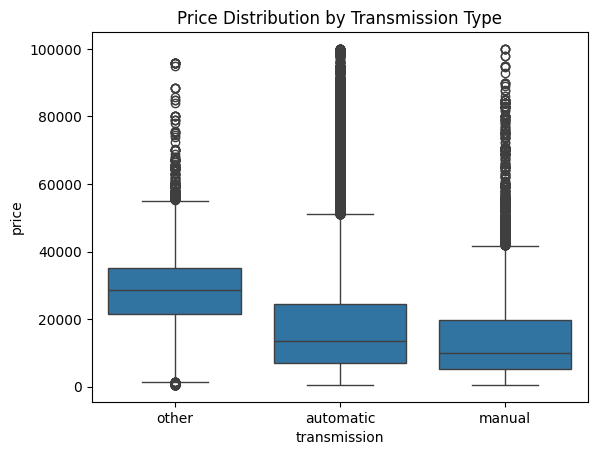

In [69]:
sns.boxplot(x="transmission", y="price", data=car_data)
plt.title("Price Distribution by Transmission Type")
plt.show()

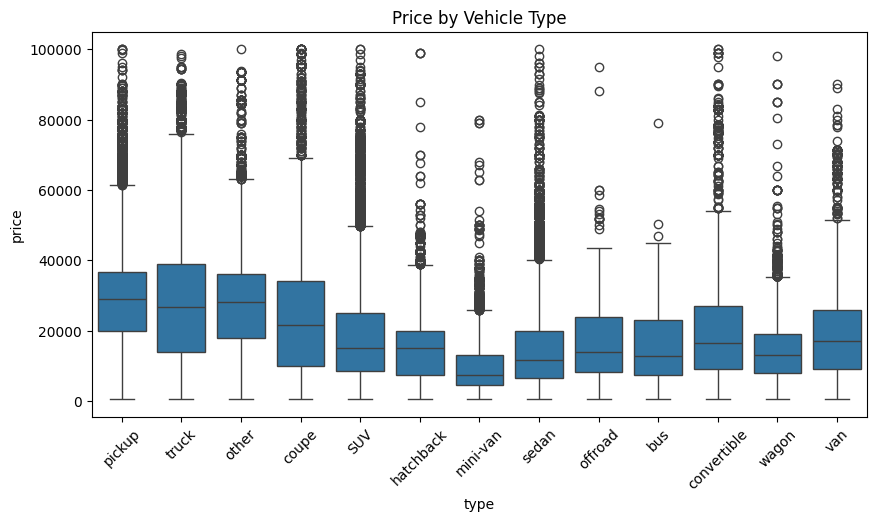

In [70]:
plt.figure(figsize=(10,5))
sns.boxplot(x="type", y="price", data=car_data)
plt.xticks(rotation=45)
plt.title("Price by Vehicle Type")
plt.show()

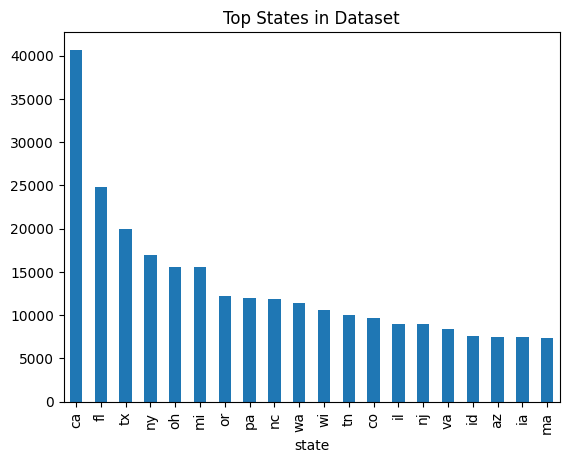

In [71]:
car_data["state"].value_counts().head(20).plot(kind="bar")
plt.title("Top States in Dataset")
plt.show()

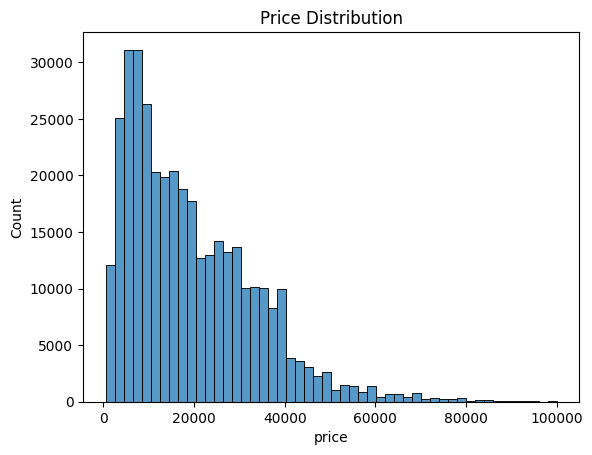

In [72]:
sns.histplot(car_data["price"], bins=50)
plt.title("Price Distribution")
plt.show()

In [75]:
car_data.fillna("unknown", inplace=True)

,region,price,manufacturer,model,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,car_age
27,auburn,33590,gmc,sierra 1500 crew cab slt,gas,57923.0,clean,other,unknown,pickup,white,al,2021-05-04T12:31:18-0500,10.0
28,auburn,22590,chevrolet,silverado 1500,gas,71229.0,clean,other,unknown,pickup,blue,al,2021-05-04T12:31:08-0500,14.0
29,auburn,39590,chevrolet,silverado 1500 crew,gas,19160.0,clean,other,unknown,pickup,red,al,2021-05-04T12:31:25-0500,4.0
30,auburn,30990,toyota,tundra double cab sr,gas,41124.0,clean,other,unknown,pickup,red,al,2021-05-04T10:41:31-0500,7.0
31,auburn,15000,ford,f-150 xlt,gas,128000.0,clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,nissan,other,gas,32226.0,clean,other,fwd,sedan,unknown,wy,2021-04-04T03:21:31-0600,5.0
426876,wyoming,30590,volvo,other,gas,12029.0,clean,other,fwd,sedan,red,wy,2021-04-04T03:21:29-0600,4.0
426877,wyoming,34990,cadillac,xt4 sport suv 4d,diesel,4174.0,clean,other,unknown,hatchback,white,wy,2021-04-04T03:21:17-0600,4.0
426878,wyoming,28990,lexus,other,gas,30112.0,clean,other,fwd,sedan,silver,wy,2021-04-04T03:21:11-0600,6.0


In [76]:
car_data = car_data.drop(columns="posting_date")

In [77]:
X = car_data.drop(columns="price")
y = car_data["price"]

In [78]:
X = pd.get_dummies(X, drop_first=True)

In [79]:
X.head()

,odometer,car_age,region_abilene,region_akron / canton,region_albany,region_albuquerque,region_altoona-johnstown,region_amarillo,region_ames,region_anchorage / mat-su,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
27,57923.0,10.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
28,71229.0,14.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29,19160.0,4.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30,41124.0,7.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31,128000.0,11.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [82]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 2136.5203853341973


In [90]:
artifacts_dir = PROJECT_ROOT / "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)
joblib.dump(model, artifacts_dir / "price_model.joblib")

['/Users/siddharth/resilient-price-engine/artifacts/price_model.joblib']

In [91]:
joblib.dump(X.columns.tolist(), artifacts_dir / "model_features.joblib")

['/Users/siddharth/resilient-price-engine/artifacts/model_features.joblib']

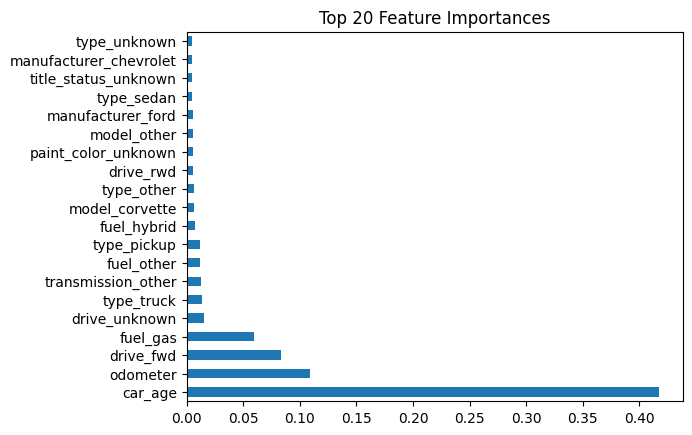

In [92]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(20).plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.show()